In [2]:
from pathlib import Path

def find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'README.md').exists() and (p / 'data').exists():
            return p
    raise FileNotFoundError('Project root not found. Make sure README.md and data/ exist.')

PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RAW_DIR =', RAW_DIR)
print('PROCESSED_DIR =', PROCESSED_DIR)

import sys
!{sys.executable} -m pip install numpy pandas matplotlib mne

import pandas as pd

hypno_df = pd.read_csv(RAW_DIR / 'sleep_edf' / 'hypno_df.csv')
hypno_df.head()


PROJECT_ROOT = C:\Users\vi\sleep-neuroscience-project
RAW_DIR = C:\Users\vi\sleep-neuroscience-project\data\raw
PROCESSED_DIR = C:\Users\vi\sleep-neuroscience-project\data\processed



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\vi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

In [3]:
from mne.datasets.sleep_physionet.age import fetch_data

subjects = [0]
recordings = [1]

data_paths = fetch_data(subjects, recordings)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating C:\Users\vi\mne_data


C:\Users\vi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|#####################################| 48.3M/48.3M [00:00<00:00, 14.2GB/s]
100%|#####################################| 4.62k/4.62k [00:00<00:00, 1.69MB/s]

Download complete in 22m51s (46.1 MB)


In [4]:
raw = mne.io.read_raw_edf(data_paths[0][0], preload=True)

print(raw.info)

Extracting EDF parameters from C:\Users\vi\mne_data\physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\vi\AppData\Local\Temp\ipykernel_7556\2416773188.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_paths[0][0], preload=True)
C:\Users\vi\AppData\Local\Temp\ipykernel_7556\2416773188.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_paths[0][0], preload=True)
C:\Users\vi\AppData\Local\Temp\ipykernel_7556\2416773188.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(data_paths[0][0], preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>


In [5]:
annotations = raw.annotations
annotations_df = annotations.to_data_frame()

annotations_df.head()

,onset,duration,description


IndexError: index 0 is out of bounds for axis 0 with size 0

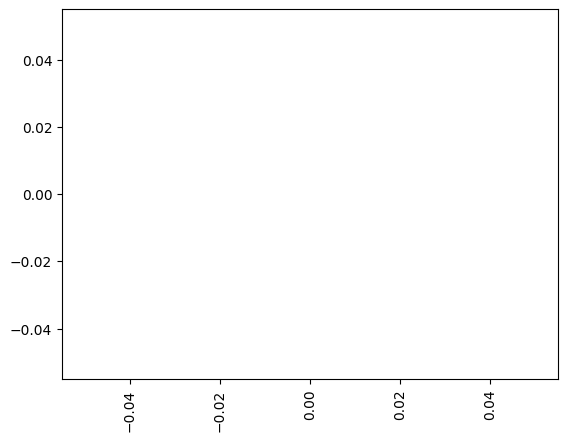

In [6]:
stage_counts = annotations_df['description'].value_counts()

stage_counts.plot(kind='bar')
plt.title("Sleep Stage Distribution")
plt.xlabel("Sleep Stage")
plt.ylabel("Count")
plt.show()

In [7]:
total = len(annotations_df)

for stage, count in stage_counts.items():
    print(stage, ":", round(count / total * 100, 2), "%")

In [8]:
transitions = (annotations_df['description'] != annotations_df['description'].shift()).sum()

print("Sleep fragmentation:", transitions)

Sleep fragmentation: 0


In [9]:
annotations_df['description'].unique()

array([], dtype=object)

In [10]:
annotations_df.head(20)

,onset,duration,description


In [11]:
wake_transitions = ((annotations_df['description'] == 'Sleep stage W') & 
                    (annotations_df['description'].shift() != 'Sleep stage W')).sum()

print("Awakenings:", wake_transitions)

Awakenings: 0


In [12]:
print("Stage transitions:", len(stage_changes))
print("Awakenings:", wake_transitions)

NameError: name 'stage_changes' is not defined

In [13]:
stages = annotations_df['description']

stage_changes = stages[stages != stages.shift()]

print("Stage transitions:", len(stage_changes))

Stage transitions: 0


In [14]:
hypno = mne.read_annotations(data_paths[0][1])
hypno.to_data_frame()

,onset,duration,description
0,1970-01-01 00:00:00,30630.0,Sleep stage W
1,1970-01-01 08:30:30,120.0,Sleep stage 1
2,1970-01-01 08:32:30,390.0,Sleep stage 2
3,1970-01-01 08:39:00,30.0,Sleep stage 3
4,1970-01-01 08:39:30,30.0,Sleep stage 2
...,...,...,...
149,1970-01-01 14:19:00,30.0,Sleep stage 1
150,1970-01-01 14:19:30,540.0,Sleep stage W
151,1970-01-01 14:28:30,150.0,Sleep stage 1
152,1970-01-01 14:31:00,27240.0,Sleep stage W


In [15]:
import pandas as pd
import numpy as np

In [16]:
expanded_stages = []

for _, row in hypno_df.iterrows():
    n_points = int(row['duration'] // 30)  # 30 сек эпохи Sleep-EDF
    expanded_stages.extend([row['description']] * n_points)

expanded_stages = pd.Series(expanded_stages)

NameError: name 'hypno_df' is not defined

In [17]:
import mne
from mne.datasets.sleep_physionet.age import fetch_data

subjects = [0]
recordings = [1]

data_paths = fetch_data(subjects, recordings)

hypno = mne.read_annotations(data_paths[0][1])
hypno_df = hypno.to_data_frame()

hypno_df.head()

Using default location ~/mne_data for PHYSIONET_SLEEP...


,onset,duration,description
0,1970-01-01 00:00:00,30630.0,Sleep stage W
1,1970-01-01 08:30:30,120.0,Sleep stage 1
2,1970-01-01 08:32:30,390.0,Sleep stage 2
3,1970-01-01 08:39:00,30.0,Sleep stage 3
4,1970-01-01 08:39:30,30.0,Sleep stage 2


In [18]:
transitions = (expanded_stages != expanded_stages.shift()).sum()

print("Sleep fragmentation:", transitions)

AttributeError: 'list' object has no attribute 'shift'

In [19]:
import pandas as pd

expanded_stages = pd.Series(expanded_stages)

transitions = (expanded_stages != expanded_stages.shift()).sum()

print("Sleep fragmentation:", transitions)

Sleep fragmentation: 0


In [20]:
expanded_stages.value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

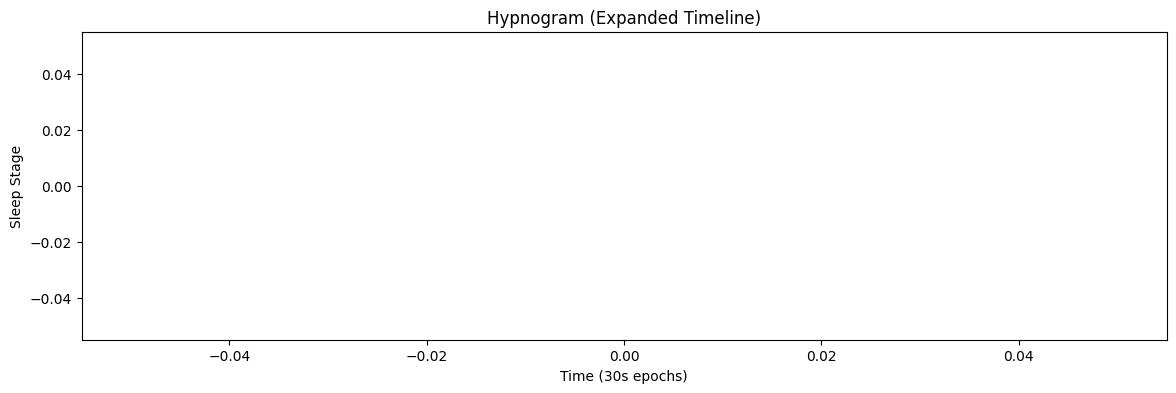

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(expanded_stages.astype('category').cat.codes)
plt.title("Hypnogram (Expanded Timeline)")
plt.xlabel("Time (30s epochs)")
plt.ylabel("Sleep Stage")
plt.show()

In [22]:
len(expanded_stages)

0

In [23]:
expanded_stages = []

for _, row in hypno_df.iterrows():
    n_points = max(1, int(row['duration'] / 30))  # 👈 ВАЖНО: /
    expanded_stages.extend([row['description']] * n_points)

import pandas as pd
expanded_stages = pd.Series(expanded_stages)

print("Length:", len(expanded_stages))

Length: 2880


In [24]:
print(hypno_df['duration'].describe())
print(hypno_df['duration'].head(10))

count      154.000000
mean       561.038961
std       3324.759398
min         30.000000
25%         30.000000
50%         60.000000
75%        150.000000
max      30630.000000
Name: duration, dtype: float64
0    30630.0
1      120.0
2      390.0
3       30.0
4       30.0
5      150.0
6       30.0
7       60.0
8       60.0
9       30.0
Name: duration, dtype: float64


In [25]:
hypno_df['description'].value_counts()

description
Sleep stage 3    48
Sleep stage 2    40
Sleep stage 1    24
Sleep stage 4    23
Sleep stage W    12
Sleep stage R     6
Sleep stage ?     1
Name: count, dtype: int64

In [26]:
stage_duration = hypno_df.groupby('description')['duration'].sum()

stage_duration

description
Sleep stage 1     1740.0
Sleep stage 2     7500.0
Sleep stage 3     3030.0
Sleep stage 4     3570.0
Sleep stage ?     6900.0
Sleep stage R     3750.0
Sleep stage W    59910.0
Name: duration, dtype: float64

In [27]:
(stage_duration / stage_duration.sum()) * 100

description
Sleep stage 1     2.013889
Sleep stage 2     8.680556
Sleep stage 3     3.506944
Sleep stage 4     4.131944
Sleep stage ?     7.986111
Sleep stage R     4.340278
Sleep stage W    69.340278
Name: duration, dtype: float64

In [28]:
transitions = (hypno_df['description'] != hypno_df['description'].shift()).sum()

print("Sleep stage transitions:", transitions)

Sleep stage transitions: 154


In [29]:
total_duration_hours = hypno_df['duration'].sum() / 3600

fragmentation_index = 154 / total_duration_hours

print(fragmentation_index)

6.416666666666667


In [30]:
stage_duration = hypno_df.groupby('description')['duration'].sum()

(stage_duration / stage_duration.sum()) * 100

description
Sleep stage 1     2.013889
Sleep stage 2     8.680556
Sleep stage 3     3.506944
Sleep stage 4     4.131944
Sleep stage ?     7.986111
Sleep stage R     4.340278
Sleep stage W    69.340278
Name: duration, dtype: float64

In [31]:
print("Total sleep time (hrs):", hypno_df['duration'].sum() / 3600)
print("Transitions:", 154)
print("Unique stages:", hypno_df['description'].nunique())

Total sleep time (hrs): 24.0
Transitions: 154
Unique stages: 7


In [32]:
df = hypno_df.copy()

df = df[~df['description'].str.contains('\?')]

<>:3: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
<>:3: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
C:\Users\vi\AppData\Local\Temp\ipykernel_7556\2031665774.py:3: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
  df = df[~df['description'].str.contains('\?')]


In [33]:
df = hypno_df.copy()

df = df[~df['description'].str.contains('?', regex=False, na=False)]

In [34]:
total_time = df['duration'].sum()
print("Total sleep time (sec):", total_time)


Total sleep time (sec): 79500.0


In [35]:
stage_time = df.groupby('description')['duration'].sum()
stage_pct = stage_time / total_time * 100


In [36]:
features['rem_pct'] = stage_pct.get('Sleep stage R', 0)

features['deep_sleep_pct'] = (
    stage_pct.get('Sleep stage 3', 0) +
    stage_pct.get('Sleep stage 4', 0)
)

features['wake_pct'] = stage_pct.get('Sleep stage W', 0)
⚡ Sleep efficiency
features['sleep_efficiency'] = (
    (total_time - df[df['description'] == 'Sleep stage W']['duration'].sum())
    / total_time


SyntaxError: invalid character '⚡' (U+26A1) (2237680332.py, line 9)

In [37]:
import pandas as pd

df = hypno_df.copy()

df = df[~df['description'].str.contains('?', regex=False, na=False)]

total_time = df['duration'].sum()
print("Total sleep time (sec):", total_time)

stage_time = df.groupby('description')['duration'].sum()
stage_pct = stage_time / total_time * 100

print(stage_pct)

features = {}

features['total_sleep_hours'] = total_time / 3600
features['fragmentation'] = (df['description'] != df['description'].shift()).sum()

features['rem_pct'] = stage_pct.get('Sleep stage R', 0)

features['deep_sleep_pct'] = (
    stage_pct.get('Sleep stage 3', 0) +
    stage_pct.get('Sleep stage 4', 0)
)

features['wake_pct'] = stage_pct.get('Sleep stage W', 0)

features['sleep_efficiency'] = (
    (total_time - df[df['description'] == 'Sleep stage W']['duration'].sum())
    / total_time
)

features_df = pd.DataFrame([features])

print(features_df)

Total sleep time (sec): 79500.0
description
Sleep stage 1     2.188679
Sleep stage 2     9.433962
Sleep stage 3     3.811321
Sleep stage 4     4.490566
Sleep stage R     4.716981
Sleep stage W    75.358491
Name: duration, dtype: float64
   total_sleep_hours  fragmentation   rem_pct  deep_sleep_pct   wake_pct  \
0          22.083333            153  4.716981        8.301887  75.358491   

   sleep_efficiency  
0          0.246415  


In [38]:
import pandas as pd

features_df = pd.DataFrame([features])

features_df


,total_sleep_hours,fragmentation,rem_pct,deep_sleep_pct,wake_pct,sleep_efficiency
0,22.083333,153,4.716981,8.301887,75.358491,0.246415


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = hypno_df.copy()

df = df[~df['description'].str.contains('?', regex=False, na=False)].copy()

df = df[df['duration'] > 0].copy()

df.head()

,onset,duration,description
0,1970-01-01 00:00:00,30630.0,Sleep stage W
1,1970-01-01 08:30:30,120.0,Sleep stage 1
2,1970-01-01 08:32:30,390.0,Sleep stage 2
3,1970-01-01 08:39:00,30.0,Sleep stage 3
4,1970-01-01 08:39:30,30.0,Sleep stage 2


In [42]:
print("Shape:", df.shape)
print("\nUnique stages:")
print(df['description'].value_counts())

Shape: (153, 3)

Unique stages:
description
Sleep stage 3    48
Sleep stage 2    40
Sleep stage 1    24
Sleep stage 4    23
Sleep stage W    12
Sleep stage R     6
Name: count, dtype: int64


In [43]:
total_time = df['duration'].sum()

stage_time = df.groupby('description')['duration'].sum().sort_values(ascending=False)
stage_hours = stage_time / 3600
stage_pct = stage_time / total_time * 100

stage_summary = pd.DataFrame({
    'duration_sec': stage_time,
    'duration_hours': stage_hours,
    'percent': stage_pct
})

stage_summary

,duration_sec,duration_hours,percent
description,,,
Sleep stage W,59910.0,16.641667,75.358491
Sleep stage 2,7500.0,2.083333,9.433962
Sleep stage R,3750.0,1.041667,4.716981
Sleep stage 4,3570.0,0.991667,4.490566
Sleep stage 3,3030.0,0.841667,3.811321
Sleep stage 1,1740.0,0.483333,2.188679


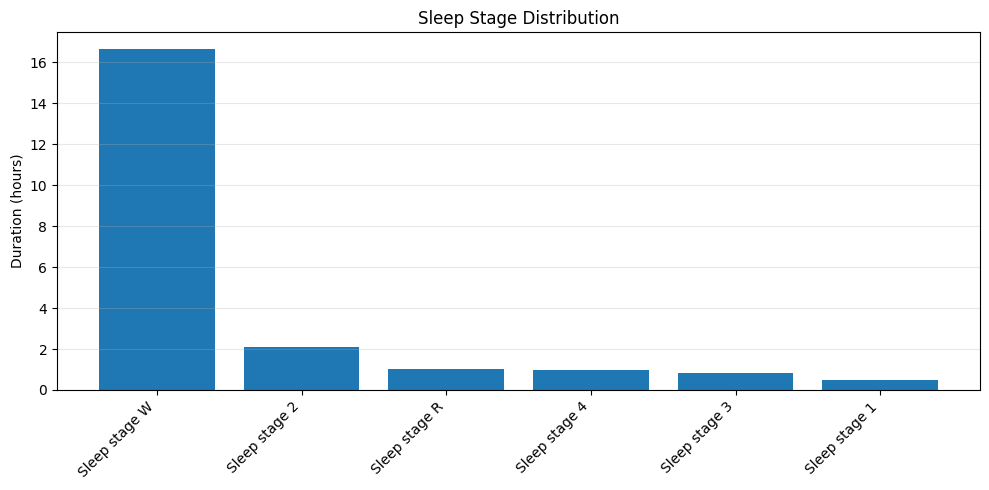

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(stage_summary.index, stage_summary['duration_hours'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Duration (hours)')
plt.title('Sleep Stage Distribution')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [45]:
print("First 20 rows:")
display(df[['description', 'duration']].head(20))

print("Last 20 rows:")
display(df[['description', 'duration']].tail(20))

First 20 rows:


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0
5,Sleep stage 3,150.0
6,Sleep stage 4,30.0
7,Sleep stage 3,60.0
8,Sleep stage 4,60.0
9,Sleep stage 3,30.0


Last 20 rows:


,description,duration
133,Sleep stage 3,30.0
134,Sleep stage 2,30.0
135,Sleep stage 3,30.0
136,Sleep stage 2,30.0
137,Sleep stage 3,120.0
138,Sleep stage 2,210.0
139,Sleep stage 3,30.0
140,Sleep stage 2,120.0
141,Sleep stage 1,60.0
142,Sleep stage R,990.0


In [46]:
print("First 20 rows:")
display(df[['description', 'duration']].head(20))

print("Last 20 rows:")
display(df[['description', 'duration']].tail(20))

First 20 rows:


,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0
5,Sleep stage 3,150.0
6,Sleep stage 4,30.0
7,Sleep stage 3,60.0
8,Sleep stage 4,60.0
9,Sleep stage 3,30.0


Last 20 rows:


,description,duration
133,Sleep stage 3,30.0
134,Sleep stage 2,30.0
135,Sleep stage 3,30.0
136,Sleep stage 2,30.0
137,Sleep stage 3,120.0
138,Sleep stage 2,210.0
139,Sleep stage 3,30.0
140,Sleep stage 2,120.0
141,Sleep stage 1,60.0
142,Sleep stage R,990.0


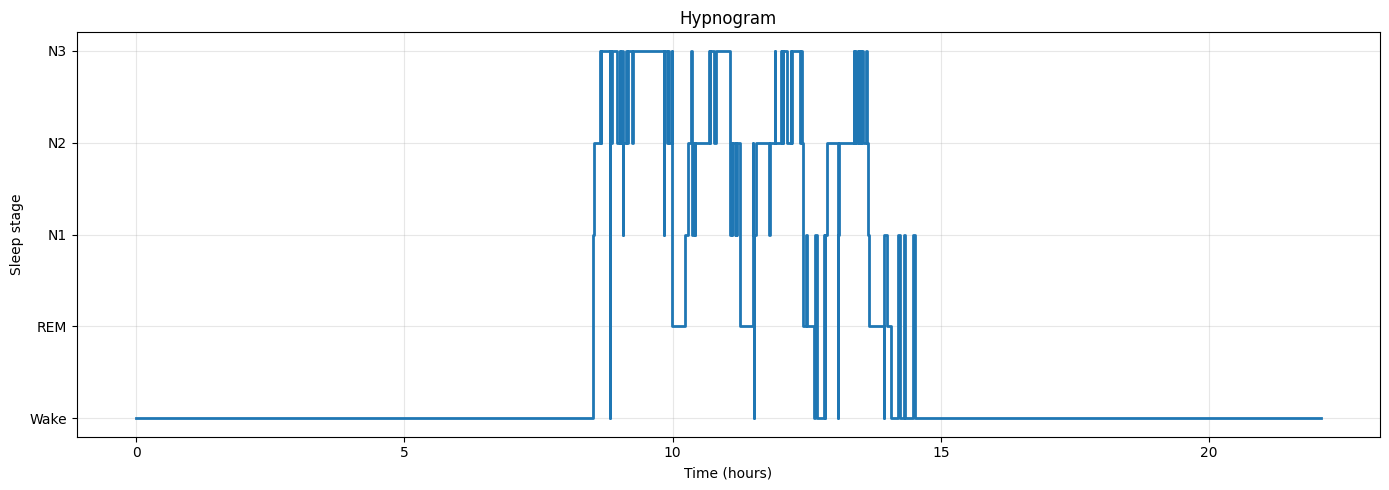

In [47]:
stage_map = {
    'Sleep stage W': 4,
    'Sleep stage R': 3,
    'Sleep stage 1': 2,
    'Sleep stage 2': 1,
    'Sleep stage 3': 0,
    'Sleep stage 4': 0
}

stage_labels = {
    4: 'Wake',
    3: 'REM',
    2: 'N1',
    1: 'N2',
    0: 'N3'
}

plot_df = df[df['description'].isin(stage_map.keys())].copy()
plot_df['stage_num'] = plot_df['description'].map(stage_map)

x = []
y = []
current_time = 0

for _, row in plot_df.iterrows():
    start = current_time / 3600
    end = (current_time + row['duration']) / 3600
    stage = row['stage_num']
    
    x.extend([start, end])
    y.extend([stage, stage])
    
    current_time += row['duration']

plt.figure(figsize=(14, 5))
plt.step(x, y, where='post', linewidth=2)

plt.yticks(list(stage_labels.keys()), [stage_labels[k] for k in stage_labels.keys()])
plt.gca().invert_yaxis()
plt.xlabel('Time (hours)')
plt.ylabel('Sleep stage')
plt.title('Hypnogram')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
features = {}

features['total_sleep_hours'] = total_time / 3600
features['fragmentation'] = (df['description'] != df['description'].shift()).sum()

features['rem_pct'] = stage_pct.get('Sleep stage R', 0)

features['deep_sleep_pct'] = (
    stage_pct.get('Sleep stage 3', 0) +
    stage_pct.get('Sleep stage 4', 0)
)

features['wake_pct'] = stage_pct.get('Sleep stage W', 0)

wake_time = df[df['description'] == 'Sleep stage W']['duration'].sum()
features['sleep_efficiency'] = (
    (total_time - wake_time) / total_time if total_time > 0 else np.nan
)

features_df = pd.DataFrame([features])
features_df

,total_sleep_hours,fragmentation,rem_pct,deep_sleep_pct,wake_pct,sleep_efficiency
0,22.083333,153,4.716981,8.301887,75.358491,0.246415


In [49]:
print("Sleep Exploration Summary")
print("-------------------------")
print(f"Total recording time: {features['total_sleep_hours']:.2f} h")
print(f"Fragmentation: {features['fragmentation']}")
print(f"REM %: {features['rem_pct']:.2f}")
print(f"Deep sleep %: {features['deep_sleep_pct']:.2f}")
print(f"Wake %: {features['wake_pct']:.2f}")
print(f"Sleep efficiency: {features['sleep_efficiency']:.2%}")

Sleep Exploration Summary
-------------------------
Total recording time: 22.08 h
Fragmentation: 153
REM %: 4.72
Deep sleep %: 8.30
Wake %: 75.36
Sleep efficiency: 24.64%


In [50]:
comments = []

if features['total_sleep_hours'] > 12:
    comments.append("Recording duration is unusually long for a single night.")

if features['wake_pct'] > 30:
    comments.append("Wake percentage is high, suggesting long wake periods in the recording.")

if features['sleep_efficiency'] < 0.7:
    comments.append("Sleep efficiency is low, which may indicate that the full recording window is being used instead of the actual sleep period.")

if len(comments) == 0:
    comments.append("Basic sanity check looks reasonable.")

print("Sanity Check")
print("------------")
for c in comments:
    print("-", c)

Sanity Check
------------
- Recording duration is unusually long for a single night.
- Wake percentage is high, suggesting long wake periods in the recording.
- Sleep efficiency is low, which may indicate that the full recording window is being used instead of the actual sleep period.


## Exploration conclusion

The recording was explored at the stage level using sleep stage durations and a hypnogram.

Key observations:
- Sleep stage distribution was calculated.
- A hypnogram was used to visualize stage transitions across time.
- Basic sleep metrics were computed: total duration, fragmentation, REM proportion, deep sleep proportion, wake proportion, and sleep efficiency.
- The unusually high wake proportion / long total duration suggests that additional preprocessing may be needed before feature engineering.

Next step:
Refine sleep-period logic and move to `02_feature_engineering.ipynb`, where sleep metrics will be formalized into reusable features for machine learning.

In [51]:
hypno_df = df[['description', 'duration']].copy()
hypno_df.to_csv('hypno_df.csv', index=False)
hypno_df.head(20)

,description,duration
0,Sleep stage W,30630.0
1,Sleep stage 1,120.0
2,Sleep stage 2,390.0
3,Sleep stage 3,30.0
4,Sleep stage 2,30.0
5,Sleep stage 3,150.0
6,Sleep stage 4,30.0
7,Sleep stage 3,60.0
8,Sleep stage 4,60.0
9,Sleep stage 3,30.0


In [3]:
hypno_df.to_csv(RAW_DIR / 'sleep_edf' / 'hypno_df.csv', index=False)